# Convolutionair Neuraal Netwerk (CNN)
Een Convolutionair Neuraal Netwerk (CNN) is een type kunstmatig neuraal netwerk dat voornamelijk wordt gebruikt voor het verwerken van gestructureerde gegevens zoals afbeeldingen. CNN's maken gebruik van convolutionele lagen die filters toepassen op de invoerdata om kenmerken te extraheren, gevolgd door pooling-lagen die de ruimtelijke dimensies van de gegevens verminderen. Dit maakt CNN's bijzonder effectief voor taken zoals beeldclassificatie, objectdetectie en gezichtsherkenning.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import tensorflow as tf


# Add the parent directory (project root) to Python path
project_root = os.path.abspath('..')  # Go up one level from current notebook
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from utils.whole_dataset_tf import create_libs_tensorflow_dataset_from_dataframe_normalized, create_libs_tensorflow_dataset_multi_output

In [2]:
df = pd.read_csv('data/csv/processed_data_with_brands.csv')

In [3]:
df.head()

,tire_number,origin,measurement_id,200.0,200.1,200.2,200.3,200.4,200.5,200.6,...,999.2,999.3,999.4,999.5,999.6,999.7,999.8,999.9,1000.0,brand
0,1,tread,0,-0.335890,-0.355886,-0.322844,-0.346300,-0.319792,-0.372075,-0.337113,...,-0.334181,-0.310245,-0.332817,-0.311960,-0.324927,-0.308685,-0.327803,-0.292344,-0.317612,Goldline
1,1,tread,1,-0.256134,-0.280616,-0.237121,-0.295053,-0.240228,-0.305715,-0.231469,...,-0.202559,-0.165180,-0.190928,-0.181072,-0.187943,-0.127377,-0.170938,-0.122243,-0.170660,Goldline
2,1,tread,2,-0.302371,-0.316509,-0.254772,-0.319493,-0.262815,-0.339551,-0.299947,...,-0.224997,-0.176060,-0.197946,-0.167356,-0.197469,-0.139063,-0.201426,-0.112672,-0.183888,Goldline
3,1,tread,3,-0.316649,-0.343836,-0.308309,-0.345271,-0.278794,-0.389061,-0.286749,...,-0.285627,-0.209622,-0.254167,-0.212382,-0.237388,-0.130450,-0.223062,-0.132415,-0.201408,Goldline
4,1,tread,4,-0.309983,-0.355262,-0.312979,-0.339325,-0.306509,-0.372496,-0.283477,...,-0.207697,-0.173115,-0.187645,-0.141835,-0.166434,-0.092824,-0.139317,-0.084642,-0.122261,Goldline


In [4]:
# First, check what brand values actually exist in the DataFrame
print("Unique brands in DataFrame:")
print(df['brand'].unique())
print(f"\nTotal unique brands: {df['brand'].nunique()}")
print(f"\nBrand value counts:")
print(df['brand'].value_counts())

# Filter dataframe to include only specific brands (case-insensitive)
brands_to_include = ['continental', 'michelin', 'hankook', 'bridgestone', 'vredestein', 'pirelli']

# Convert both to lowercase for comparison
df = df[df['brand'].str.lower().isin(brands_to_include)]


print(f"Filtered dataset to {len(df):,} samples")
print(f"\nBrand distribution after filtering:")
print(df['brand'].value_counts())

Unique brands in DataFrame:
['Goldline' 'T TYRE 3' 'ATLAS' 'NOVEX' 'GT RADIAL' 'TRISTAR' 'BRIDGESTONE'
 'VREDESTEIN' 'HANKOOK' 'CONTINENTAL' 'MICHELIN' 'NEXEN' 'TORQUE'
 'FIRESTONE' 'LANDSAIL' 'GOODYEAR' 'GITI' 'DUNLOP' 'NORDEXX' 'TYFOON'
 'KUMHO' 'ARROWSPEED' 'TOYO' 'KABILERO' 'PIRELLI' 'HIFLY' 'DYNAMO'
 'GENERAL' 'GOODRIDE' 'NANKANG' 'UNIROYAL' 'VIKING' 'MAXXIS' 'RADAR'
 'FULDA' 'FALKEN' 'LANVIGATOR']

Total unique brands: 37

Brand value counts:
brand
CONTINENTAL    8567
HANKOOK        5181
MICHELIN       4133
BRIDGESTONE    3781
VREDESTEIN     3696
PIRELLI        2886
DUNLOP         2369
HIFLY          1815
KUMHO          1514
GOODYEAR       1345
MAXXIS         1212
NANKANG        1165
LANDSAIL        860
TOYO            802
NEXEN           795
Goldline        766
RADAR           761
GITI            731
FULDA           701
FALKEN          626
VIKING          618
UNIROYAL        574
NOVEX           551
TYFOON          545
T TYRE 3        512
KABILERO        498
ATLAS           470
N

In [5]:
df.head()

,tire_number,origin,measurement_id,200.0,200.1,200.2,200.3,200.4,200.5,200.6,...,999.2,999.3,999.4,999.5,999.6,999.7,999.8,999.9,1000.0,brand
3159,7,tread,0,-0.324405,-0.352708,-0.342949,-0.356508,-0.330633,-0.377455,-0.332722,...,-0.343125,-0.316425,-0.320931,-0.302466,-0.316236,-0.290915,-0.328004,-0.284511,-0.302055,BRIDGESTONE
3160,7,tread,1,-0.363449,-0.374154,-0.354180,-0.377699,-0.359279,-0.389402,-0.368266,...,-0.334395,-0.305210,-0.317194,-0.293455,-0.324861,-0.257244,-0.301857,-0.255211,-0.285456,BRIDGESTONE
3161,7,tread,2,-0.345481,-0.362976,-0.333427,-0.359785,-0.347283,-0.388300,-0.348869,...,-0.346830,-0.322014,-0.337085,-0.317047,-0.324282,-0.304930,-0.327507,-0.287361,-0.305166,BRIDGESTONE
3162,7,tread,3,-0.332681,-0.355705,-0.325066,-0.341420,-0.326850,-0.372613,-0.327425,...,-0.349411,-0.319970,-0.335401,-0.322336,-0.331102,-0.307125,-0.329534,-0.291916,-0.320086,BRIDGESTONE
3163,7,tread,4,-0.323718,-0.344422,-0.319938,-0.330959,-0.318095,-0.362362,-0.319804,...,-0.332728,-0.301437,-0.318240,-0.312775,-0.327645,-0.292809,-0.318010,-0.284466,-0.308053,BRIDGESTONE


In [ ]:
train_dataset, val_dataset, test_dataset, label_encoder, dataset_info = create_libs_tensorflow_dataset_from_dataframe_normalized(df, batch_size=64, normalize_data=False, include_brands=True)

🎯 Using BRAND as target variable
📊 Processing DataFrame with 28,244 samples...
🔧 Dimensionality reduction: NONE
Found 8001 wavelength features
Wavelength range: 200.0 - 1000.0 nm
🔄 Extracting spectral data and labels...
🔄 Encoding labels...
Label encoding: {'BRIDGESTONE': 0, 'CONTINENTAL': 1, 'HANKOOK': 2, 'MICHELIN': 3, 'PIRELLI': 4, 'VREDESTEIN': 5}

📊 Class distribution (brand):
  BRIDGESTONE: 3,781 samples (13.4%)
  CONTINENTAL: 8,567 samples (30.3%)
  HANKOOK: 5,181 samples (18.3%)
  MICHELIN: 4,133 samples (14.6%)
  PIRELLI: 2,886 samples (10.2%)
  VREDESTEIN: 3,696 samples (13.1%)

🔄 No dimensionality reduction applied

🔄 Splitting data...
Train set: 18,076 samples
Validation set: 4,519 samples
Test set: 5,649 samples

🔄 Creating TensorFlow datasets...

🎯 TensorFlow Dataset created successfully!
   • Target variable: BRAND
   • Total samples: 28,244
   • Features per sample: 8,001 (reduced from 8,001)
   • Classes: 6 (BRIDGESTONE, CONTINENTAL, HANKOOK, MICHELIN, PIRELLI...)
   •

In [7]:
print(dataset_info)

{'total_samples': 28244, 'train_samples': 18076, 'val_samples': 4519, 'test_samples': 5649, 'n_features': 8001, 'original_n_features': 8001, 'n_classes': 6, 'class_names': ['BRIDGESTONE', 'CONTINENTAL', 'HANKOOK', 'MICHELIN', 'PIRELLI', 'VREDESTEIN'], 'feature_shape': (8001,), 'steps_per_epoch': 282, 'validation_steps': 70, 'wavelength_range': (200.0, 1000.0), 'target_column': 'brand', 'predicting_brands': True, 'normalized': False, 'data_type': 'float32', 'dimensionality_reduction': {'method': 'none', 'n_components': 8001}}


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

input_shape = (train_dataset.element_spec[0].shape[1],)

model = keras.Sequential([
    # Input laag
    layers.Reshape((input_shape[0], 1), input_shape=input_shape),

    # 1e Conv blok
    layers.Conv1D(64, kernel_size=5, activation='swish', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.5),

    # 2e Conv blok
    layers.Conv1D(128, kernel_size=5, activation='swish', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.5),

    layers.Conv1D(128, kernel_size=5, activation='swish', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.5),

    layers.Conv1D(256, kernel_size=5, activation='swish', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.5),

    # 3e Conv blok
    layers.Conv1D(256, kernel_size=3, activation='swish', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),

    # Dense laag
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape (Reshape)           (None, 8001, 1)           0         
                                                                 
 conv1d (Conv1D)             (None, 8001, 64)          384       
                                                                 
 batch_normalization (BatchN  (None, 8001, 64)         256       
 ormalization)                                                   
                                                                 
 max_pooling1d (MaxPooling1D  (None, 4000, 64)         0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 4000, 64)          0         
                                                                 
 conv1d_1 (Conv1D)           (None, 4000, 128)         4

In [9]:
def get_callbacks(patience=5):
    """Standard callbacks for training"""
    return [
        # EarlyStopping(
        #     monitor='val_loss',
        #     patience=patience,
        #     restore_best_weights=True,
        #     verbose=1
        # ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=patience,
            min_lr=1e-7,
            verbose=1
        )
    ]

In [10]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=get_callbacks()
)
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f'Test accuracy: {test_accuracy:.4f}')

Epoch 1/100
283/283 [==============================] - 79s 250ms/step - loss: 1.8642 - accuracy: 0.2627 - val_loss: 1.8347 - val_accuracy: 0.2726 - lr: 0.0010
Epoch 2/100
283/283 [==============================] - 66s 235ms/step - loss: 1.6645 - accuracy: 0.3108 - val_loss: 2.3110 - val_accuracy: 0.1737 - lr: 0.0010
Epoch 3/100
283/283 [==============================] - 67s 235ms/step - loss: 1.6026 - accuracy: 0.3400 - val_loss: 1.8619 - val_accuracy: 0.2038 - lr: 0.0010
Epoch 4/100
283/283 [==============================] - 66s 234ms/step - loss: 1.5442 - accuracy: 0.3743 - val_loss: 1.8328 - val_accuracy: 0.2620 - lr: 0.0010
Epoch 5/100
283/283 [==============================] - 65s 230ms/step - loss: 1.4919 - accuracy: 0.4036 - val_loss: 2.0195 - val_accuracy: 0.2286 - lr: 0.0010
Epoch 6/100
283/283 [==============================] - 65s 229ms/step - loss: 1.4309 - accuracy: 0.4373 - val_loss: 2.1941 - val_accuracy: 0.2146 - lr: 0.0010
Epoch 7/100
283/283 [=========================

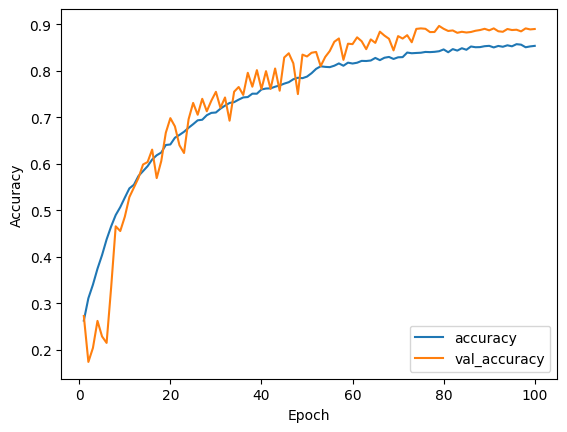

In [11]:
import matplotlib.pyplot as plt

acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
epochs=range(1, len(val_acc)+1)                        
plt.plot(epochs, acc, label='accuracy')
plt.plot(epochs, val_acc, label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

In [12]:
print(len(history.history['val_accuracy']))

100


71/71 [==============================] - 4s 56ms/step
Predictions shape: (4519, 37)
Sample predictions:
[[1.2000378e-06 9.0333563e-04 1.8785126e-05 5.8023025e-10 2.0142518e-06
  9.9907458e-01 1.0110873e-21 1.3718133e-21 1.5255540e-21 1.9464626e-21
  1.2976628e-21 1.3137106e-21 9.4469741e-22 3.6908213e-21 1.3919181e-21
  2.1084529e-21 6.4276502e-21 9.4939766e-22 1.8586601e-21 5.3926506e-22
  1.4607613e-21 1.6632853e-21 1.1077502e-21 2.0251365e-21 1.8549414e-21
  4.0293393e-21 1.8132371e-21 2.8517304e-21 3.9413787e-21 1.4237746e-21
  1.1117424e-21 3.6878377e-21 4.4165578e-22 3.0225941e-21 1.1791311e-21
  9.5594998e-22 4.5959107e-22]
 [5.9155404e-06 9.9998856e-01 1.6710787e-08 2.5331417e-06 2.9901069e-06
  2.7596135e-08 2.1629101e-21 1.0841829e-21 4.8366313e-21 3.9936034e-21
  2.9959694e-21 1.8250670e-21 4.8216907e-21 2.4715539e-21 2.5989550e-21
  3.4133701e-21 7.7216947e-21 1.3138947e-21 3.3433425e-21 1.1956348e-21
  9.2947929e-22 2.2217576e-21 2.1515456e-21 2.3706762e-21 1.2396644e-21
 

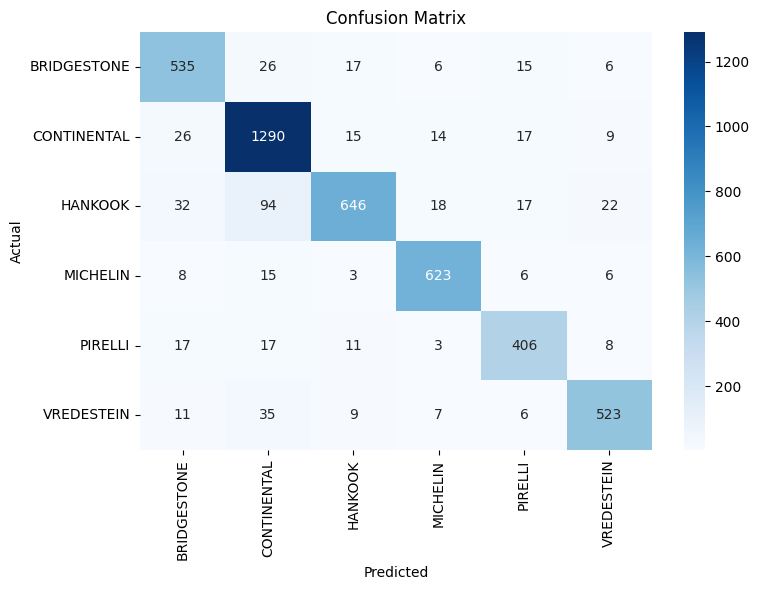


Classification Report:
              precision    recall  f1-score   support

 BRIDGESTONE       0.85      0.88      0.87       605
 CONTINENTAL       0.87      0.94      0.91      1371
     HANKOOK       0.92      0.78      0.84       829
    MICHELIN       0.93      0.94      0.94       661
     PIRELLI       0.87      0.88      0.87       462
  VREDESTEIN       0.91      0.88      0.90       591

    accuracy                           0.89      4519
   macro avg       0.89      0.89      0.89      4519
weighted avg       0.89      0.89      0.89      4519



In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions from the model
predictions = model.predict(val_dataset)
print(f"Predictions shape: {predictions.shape}")  # Should be (n_samples, 3)
print(f"Sample predictions:\n{predictions[:3]}")  # Show first 3 predictions

# Convert probabilities to class predictions using argmax
y_pred = np.argmax(predictions, axis=1)  # Convert to class indices [0, 1, 2]
print(f"Predicted classes shape: {y_pred.shape}")  # Should be (n_samples,)
print(f"Sample predicted classes: {y_pred[:10]}")  # Should be integers like [0, 1, 2, 1, 0...]

# Get true labels
y_true = np.concatenate([y for x, y in val_dataset], axis=0)
print(f"True labels shape: {y_true.shape}")  # Should be (n_samples,)
print(f"Sample true labels: {y_true[:10]}")  # Should be integers like [0, 1, 2, 1, 0...]

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix with proper labels
plt.figure(figsize=(8, 6))
class_names = label_encoder.classes_  
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=class_names, 
           yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

In [14]:
def keras_model_memory_usage_in_bytes(model, *, batch_size: int):
    """
    Return the estimated memory usage of a given Keras model in bytes.
    This includes the model weights and layers, but excludes the dataset.
    The model shapes are multipled by the batch size, but the weights are not.
    Args:
        model: A Keras model.
        batch_size: The batch size you intend to run the model with. If you
            have already specified the batch size in the model itself, then
            pass `1` as the argument here.
    Returns:
        An estimate of the Keras model's memory usage in bytes.
    """
    default_dtype = tf.keras.backend.floatx()
    shapes_mem_count = 0
    internal_model_mem_count = 0
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            internal_model_mem_count += keras_model_memory_usage_in_bytes(
                layer, batch_size=batch_size
            )
        single_layer_mem = tf.as_dtype(layer.dtype or default_dtype).size
        out_shape = layer.output_shape
        if isinstance(out_shape, list):
            out_shape = out_shape[0]
        for s in out_shape:
            if s is None:
                continue
            single_layer_mem *= s
        shapes_mem_count += single_layer_mem

    trainable_count = sum(
        [tf.keras.backend.count_params(p) for p in model.trainable_weights]
    )
    non_trainable_count = sum(
        [tf.keras.backend.count_params(p) for p in model.non_trainable_weights]
    )

    total_memory = (
        batch_size * shapes_mem_count
        + internal_model_mem_count
        + trainable_count
        + non_trainable_count
    )
    return total_memory

In [15]:
model_memory = keras_model_memory_usage_in_bytes(model, batch_size=64)
print(f"Estimated model memory usage: {model_memory / (1024 ** 2):.2f} MB")

Estimated model memory usage: 1190.22 MB


In [16]:
# Simple solution for quick inference timing
import time

# Method 1: Time the entire validation dataset
print("Timing full validation dataset prediction...")
start_time = time.perf_counter()
predictions = model.predict(val_dataset, verbose=0)
end_time = time.perf_counter()

total_time_ms = (end_time - start_time) * 1000
num_samples = predictions.shape[0]
time_per_sample = total_time_ms / num_samples

print(f"Total inference time: {total_time_ms:.2f} ms")
print(f"Number of samples: {num_samples}")
print(f"Time per sample: {time_per_sample:.4f} ms")
print(f"Samples per second: {1000/time_per_sample:.0f}")

Timing full validation dataset prediction...
Total inference time: 3987.87 ms
Number of samples: 4519
Time per sample: 0.8825 ms
Samples per second: 1133


🔬 CLASS PROTOTYPE GENERATION AND ANALYSIS
📊 Extracting validation data...
   Validation data shape: (4519, 8001)
   Classes: ['BRIDGESTONE' 'CONTINENTAL' 'HANKOOK' 'MICHELIN' 'PIRELLI' 'VREDESTEIN']

🔬 Generating Statistical Class Prototypes...
   📊 BRIDGESTONE: 605 samples
   📊 CONTINENTAL: 1371 samples
   📊 HANKOOK: 829 samples
   📊 MICHELIN: 661 samples
   📊 PIRELLI: 462 samples
   📊 VREDESTEIN: 591 samples
📈 Visualizing statistical Class Prototypes...


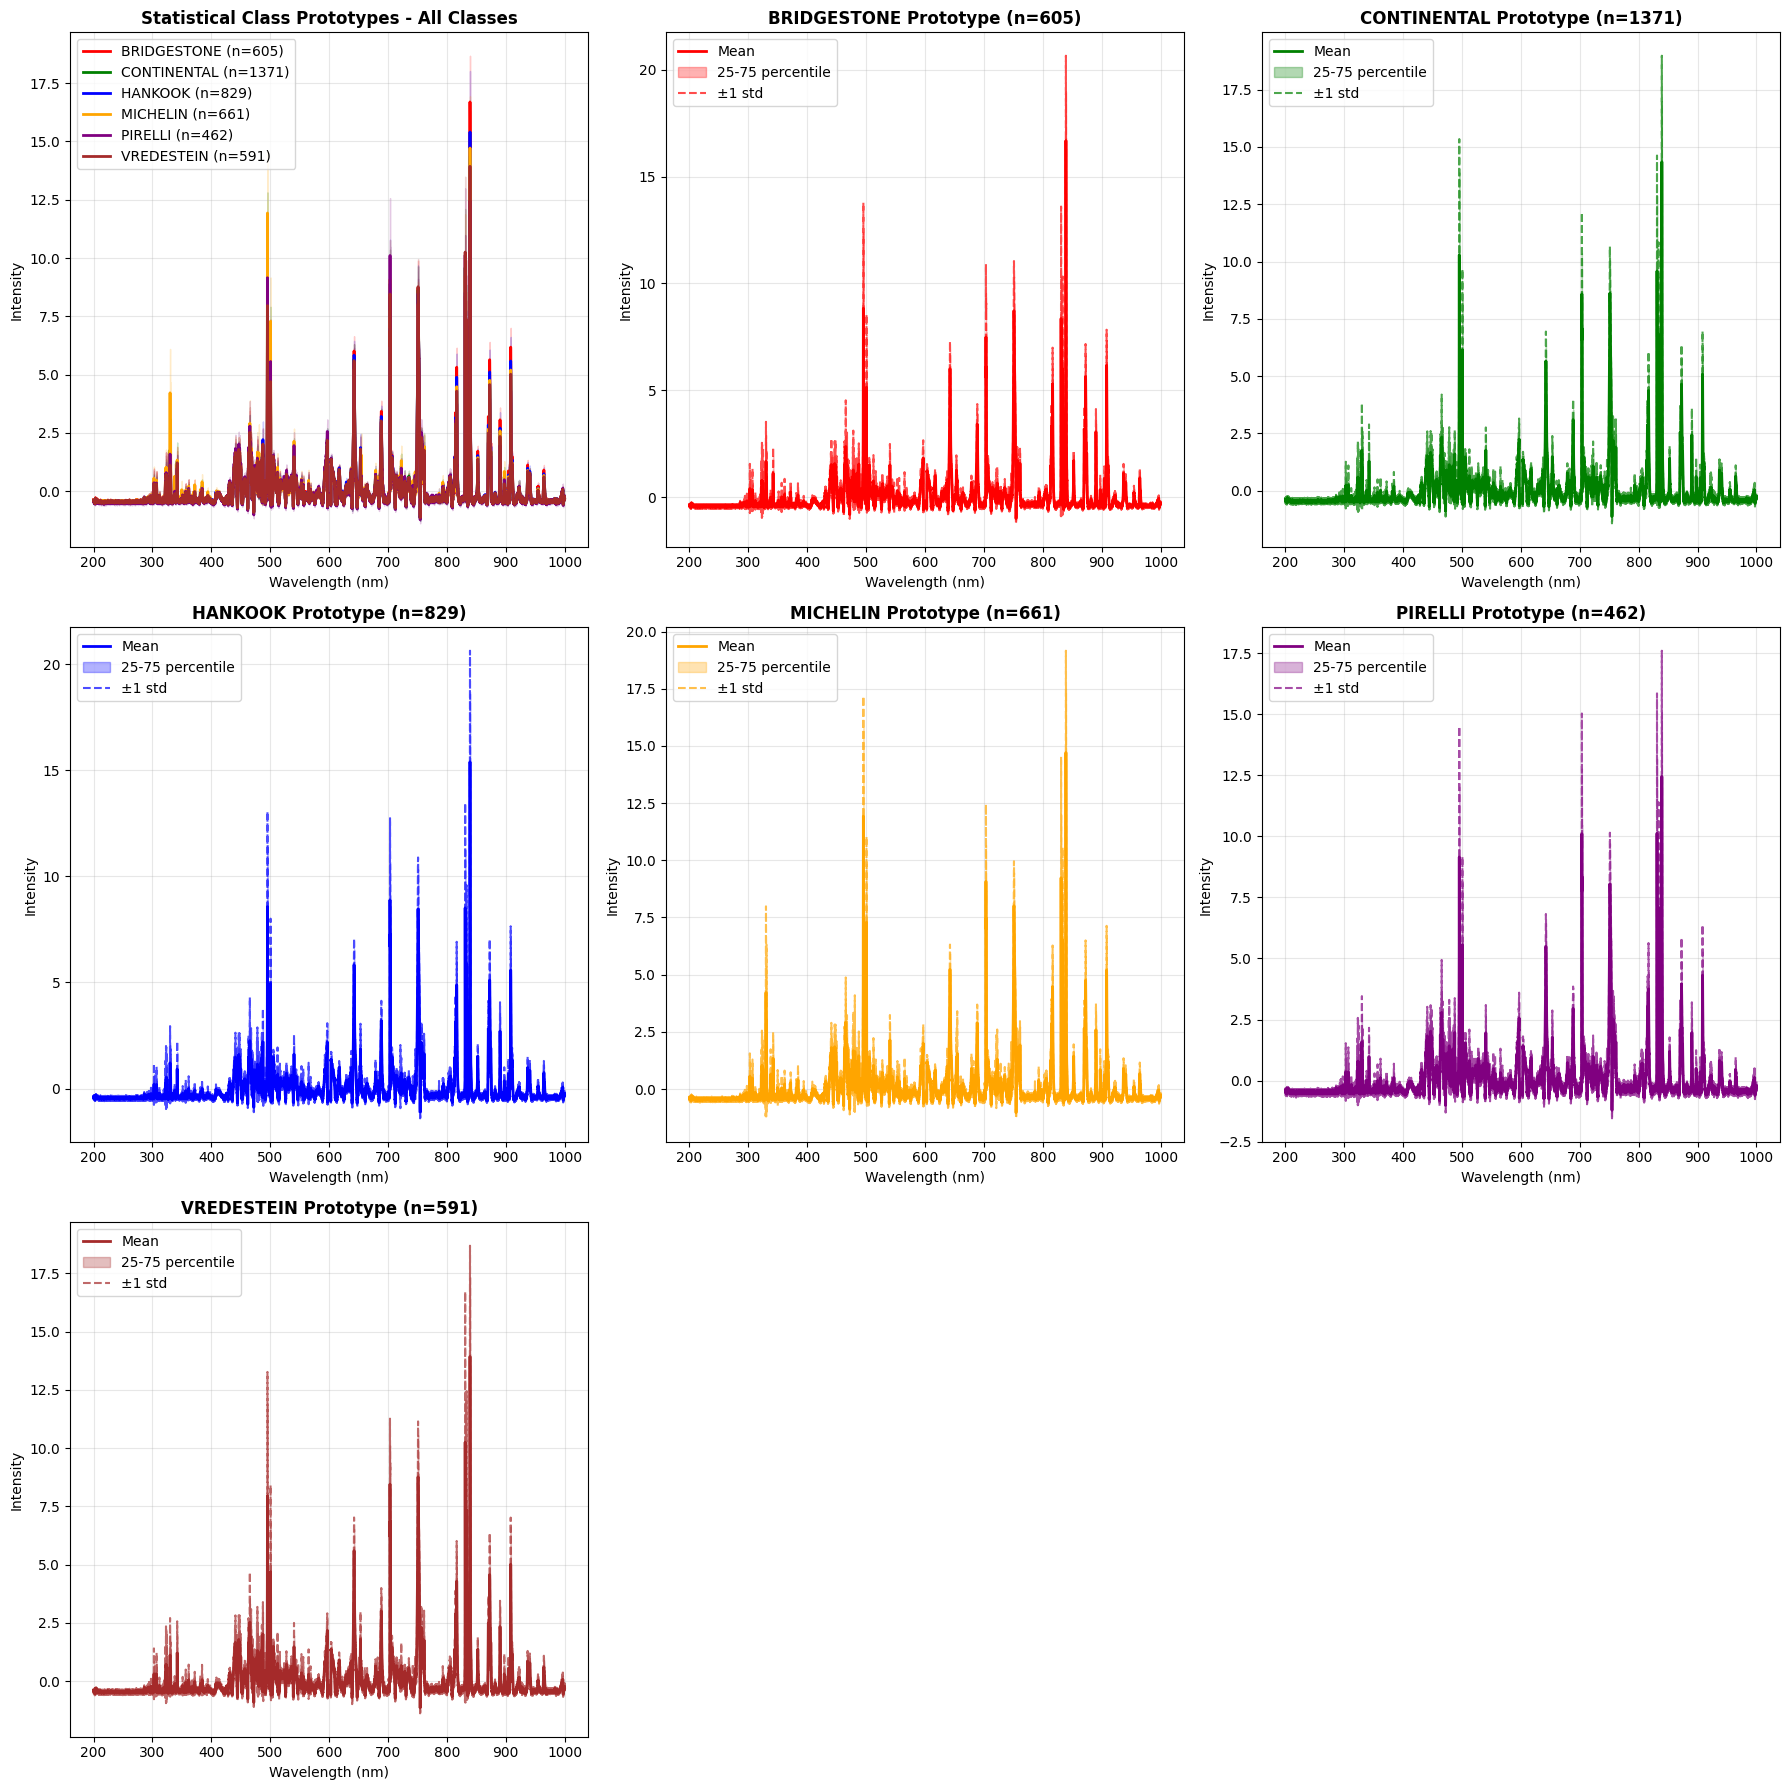

🔍 Analyzing Class Separability for statistical prototypes...

📊 Pairwise distances between class prototypes:
             BRIDGESTONE CONTINENTAL    HANKOOK   MICHELIN    PIRELLI VREDESTEIN
BRIDGESTONE        0.00      10.98       8.52      15.50      18.52      11.95 
CONTINENTAL                   0.00       7.10      11.92       9.19       6.15 
HANKOOK                                  0.00      15.45      12.20       7.02 
MICHELIN                                            0.00      15.94      15.95 
PIRELLI                                                        0.00       9.03 
VREDESTEIN                                                                0.00 

🎯 Most separable classes: BRIDGESTONE - PIRELLI (distance: 18.52)
🔍 Least separable classes: CONTINENTAL - VREDESTEIN (distance: 6.15)


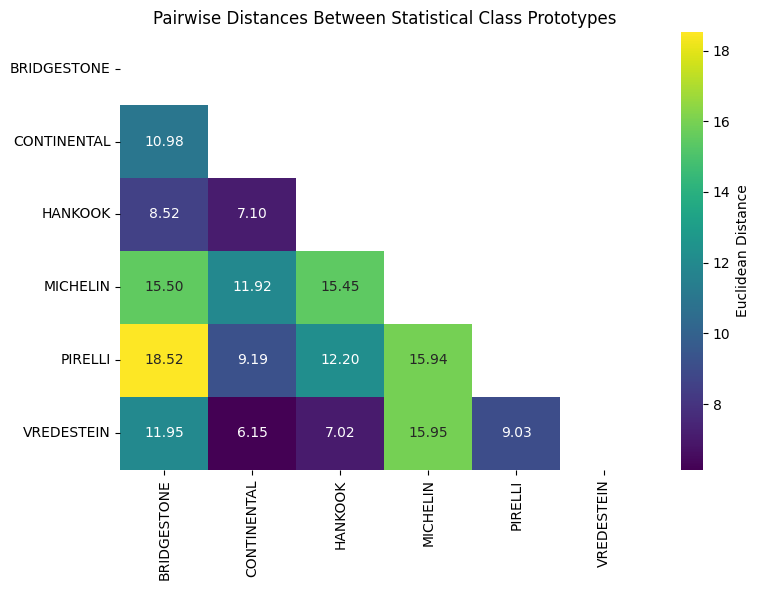


🎯 Generating Medoid Class Prototypes...
   🎯 BRIDGESTONE: Medoid from sample #3447 (605 samples)
   🎯 CONTINENTAL: Medoid from sample #3961 (1371 samples)
   🎯 HANKOOK: Medoid from sample #3255 (829 samples)
   🎯 MICHELIN: Medoid from sample #4222 (661 samples)
   🎯 PIRELLI: Medoid from sample #2730 (462 samples)
   🎯 VREDESTEIN: Medoid from sample #319 (591 samples)
📈 Visualizing medoid Class Prototypes...


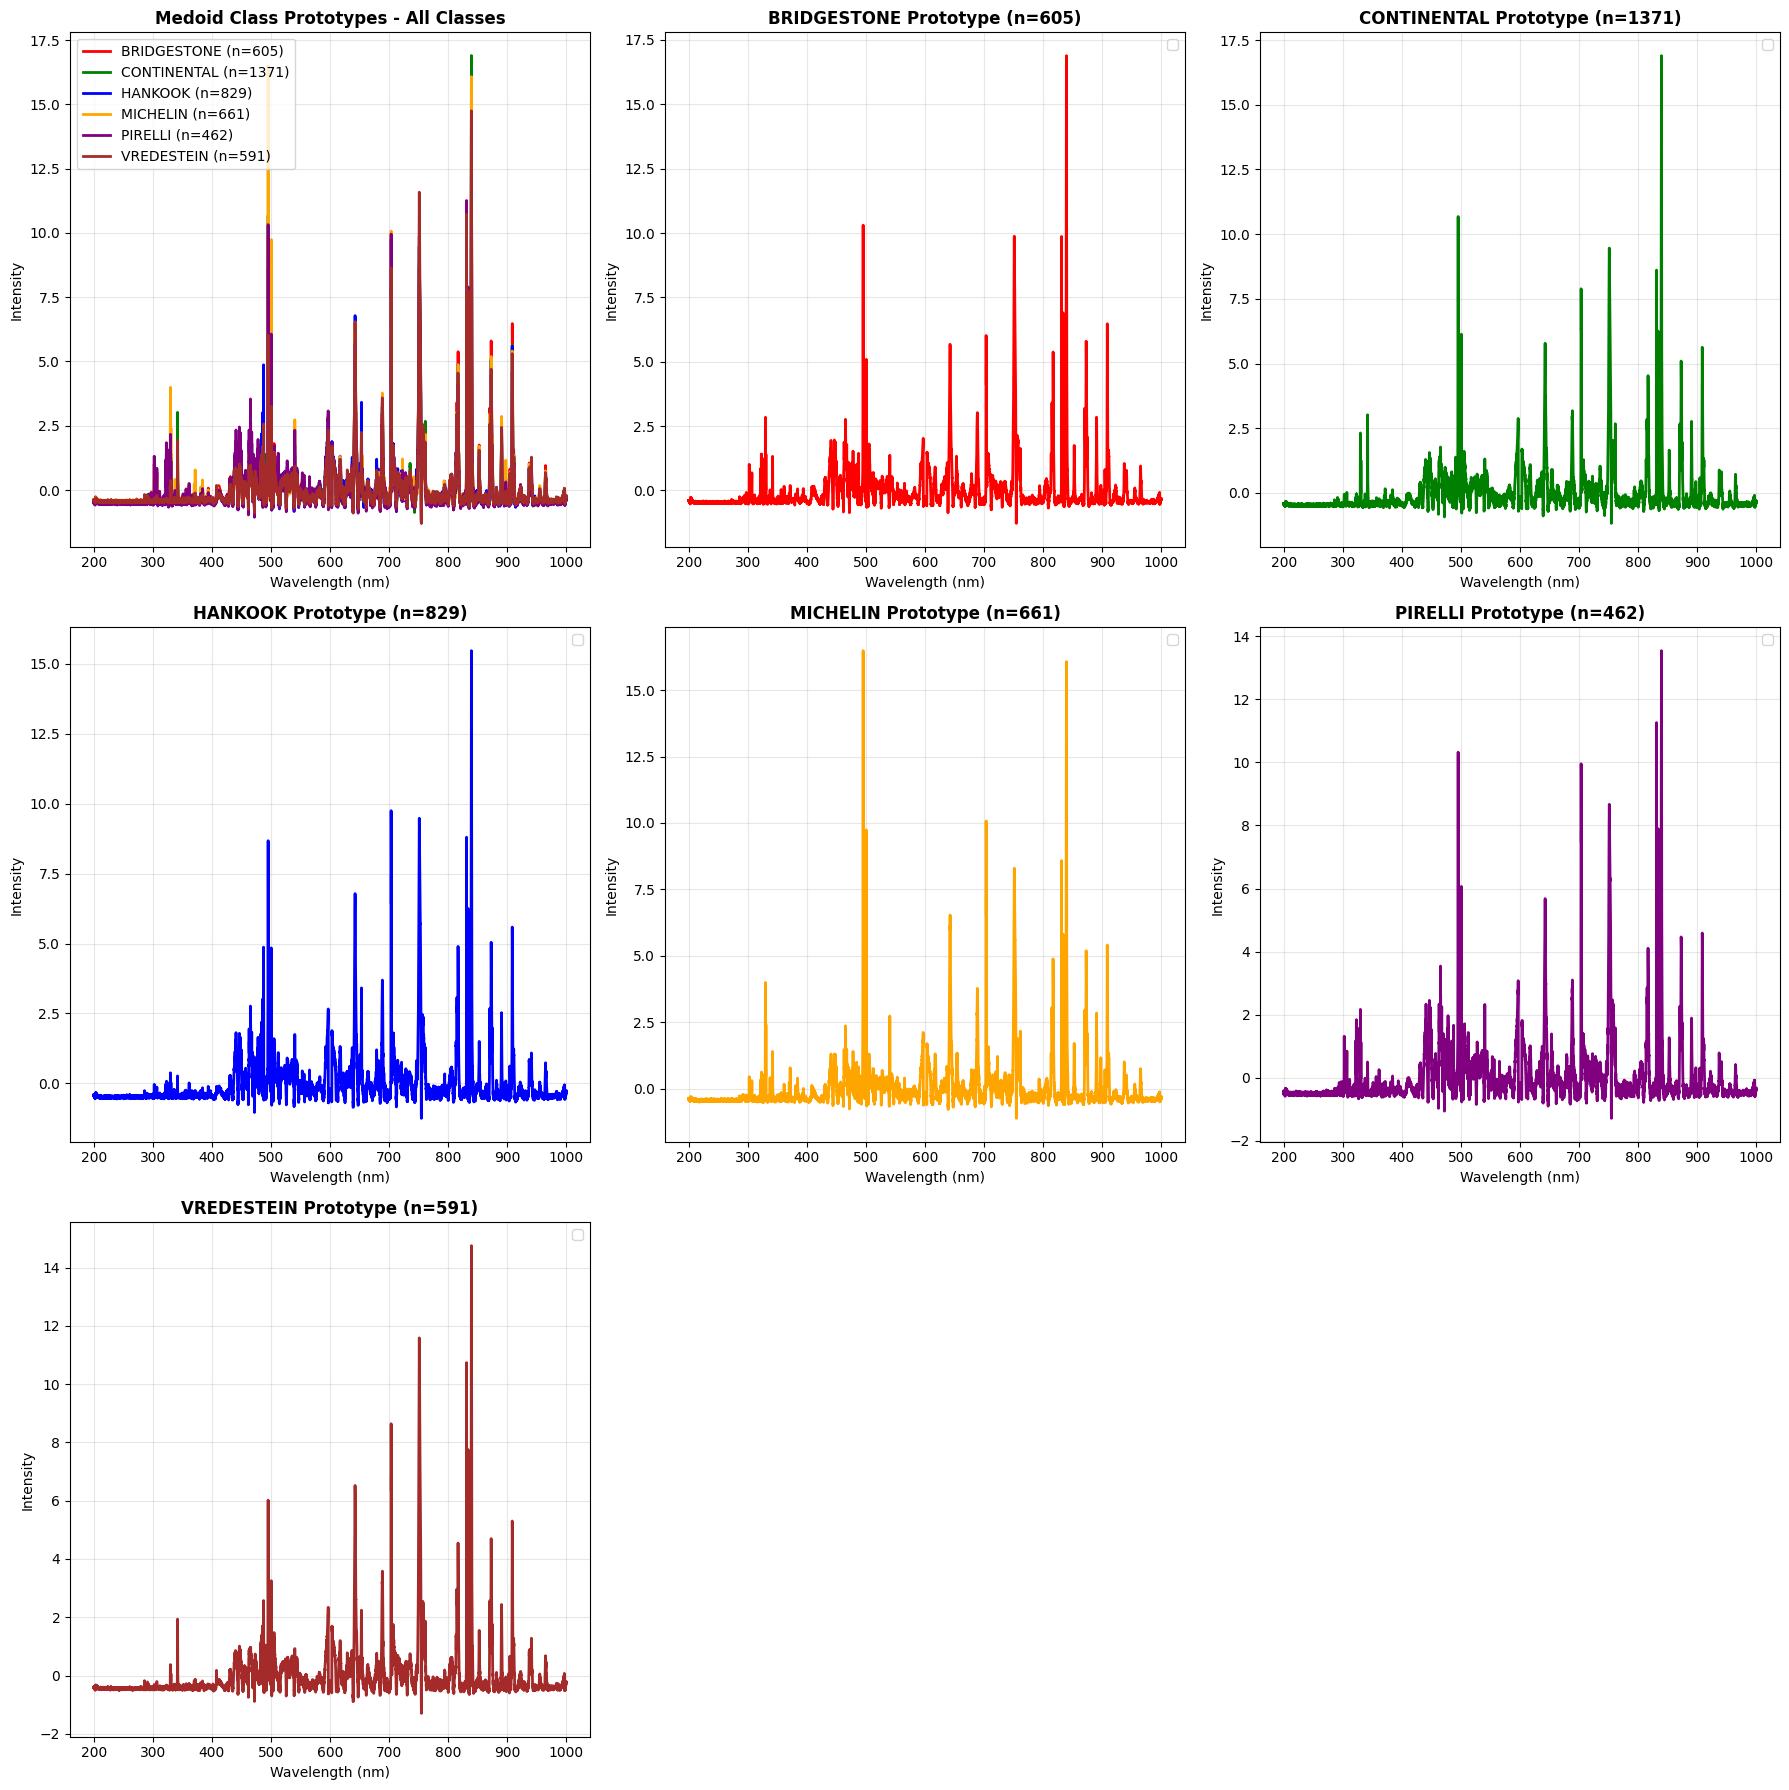

🔍 Analyzing Class Separability for medoid prototypes...

📊 Pairwise distances between class prototypes:
             BRIDGESTONE CONTINENTAL    HANKOOK   MICHELIN    PIRELLI VREDESTEIN
BRIDGESTONE        0.00      16.15      21.51      23.49      20.26      22.84 
CONTINENTAL                   0.00      21.11      18.58      18.71      20.71 
HANKOOK                                  0.00      28.04      21.04      17.02 
MICHELIN                                            0.00      23.60      31.42 
PIRELLI                                                        0.00      25.15 
VREDESTEIN                                                                0.00 

🎯 Most separable classes: MICHELIN - VREDESTEIN (distance: 31.42)
🔍 Least separable classes: BRIDGESTONE - CONTINENTAL (distance: 16.15)


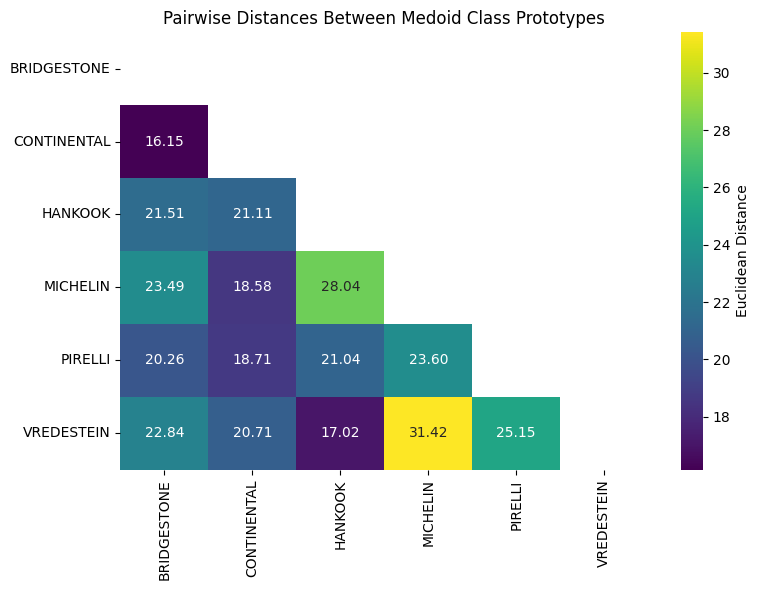


🧠 Generating Feature Space Class Prototypes...
   🧠 BRIDGESTONE: Feature prototype from 605 samples
   🧠 CONTINENTAL: Feature prototype from 1371 samples
   🧠 HANKOOK: Feature prototype from 829 samples
   🧠 MICHELIN: Feature prototype from 661 samples
   🧠 PIRELLI: Feature prototype from 462 samples
   🧠 VREDESTEIN: Feature prototype from 591 samples

🎯 Feature Space Analysis:
   BRIDGESTONE: 256 features, distance to closest: 2.4006
   CONTINENTAL: 256 features, distance to closest: 2.6154
   HANKOOK: 256 features, distance to closest: 2.3221
   MICHELIN: 256 features, distance to closest: 3.0410
   PIRELLI: 256 features, distance to closest: 2.1260
   VREDESTEIN: 256 features, distance to closest: 2.2138


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances
import tensorflow as tf

def extract_features_from_layer(model, dataset, layer_name_or_index=-3):
    """
    Extract features from a specific layer of the model
    
    Parameters:
    -----------
    model : tf.keras.Model
        Trained model
    dataset : tf.data.Dataset
        Dataset to extract features from
    layer_name_or_index : str or int
        Layer name or index to extract features from (default: -3 for second-to-last dense layer)
    
    Returns:
    --------
    features : np.array
        Extracted features
    labels : np.array
        Corresponding labels
    """
    
    # Create feature extraction model
    if isinstance(layer_name_or_index, int):
        feature_extractor = tf.keras.Model(
            inputs=model.input,
            outputs=model.layers[layer_name_or_index].output
        )
    else:
        feature_extractor = tf.keras.Model(
            inputs=model.input,
            outputs=model.get_layer(layer_name_or_index).output
        )
    
    # Extract features and labels
    features_list = []
    labels_list = []
    
    for x_batch, y_batch in dataset:
        batch_features = feature_extractor.predict(x_batch, verbose=0)
        features_list.append(batch_features)
        labels_list.append(y_batch.numpy())
    
    features = np.concatenate(features_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    
    return features, labels

def generate_class_prototypes_statistical(X_data, y_data, label_encoder):
    """
    Generate class prototypes using statistical methods (mean, median)
    
    Parameters:
    -----------
    X_data : np.array
        Input spectra data
    y_data : np.array
        Labels
    label_encoder : sklearn.preprocessing.LabelEncoder
        Label encoder
    
    Returns:
    --------
    prototypes : dict
        Dictionary containing prototypes for each class
    """
    
    print("🔬 Generating Statistical Class Prototypes...")
    
    prototypes = {}
    class_names = label_encoder.classes_
    
    for class_idx, class_name in enumerate(class_names):
        # Get all samples for this class
        class_mask = (y_data == class_idx)
        class_samples = X_data[class_mask]
        
        if len(class_samples) == 0:
            print(f"⚠️  Warning: No samples found for class {class_name}")
            continue
        
        # Calculate different prototypes
        mean_prototype = np.mean(class_samples, axis=0)
        median_prototype = np.median(class_samples, axis=0)
        std_prototype = np.std(class_samples, axis=0)
        
        # Calculate confidence intervals
        percentile_25 = np.percentile(class_samples, 25, axis=0)
        percentile_75 = np.percentile(class_samples, 75, axis=0)
        
        prototypes[class_name] = {
            'mean': mean_prototype,
            'median': median_prototype,
            'std': std_prototype,
            'percentile_25': percentile_25,
            'percentile_75': percentile_75,
            'n_samples': len(class_samples),
            'class_idx': class_idx
        }
        
        print(f"   📊 {class_name}: {len(class_samples)} samples")
    
    return prototypes

def generate_class_prototypes_medoid(X_data, y_data, label_encoder):
    """
    Generate class prototypes using medoid (most representative sample)
    
    Parameters:
    -----------
    X_data : np.array
        Input spectra data  
    y_data : np.array
        Labels
    label_encoder : sklearn.preprocessing.LabelEncoder
        Label encoder
    
    Returns:
    --------
    prototypes : dict
        Dictionary containing medoid prototypes for each class
    """
    
    print("🎯 Generating Medoid Class Prototypes...")
    
    prototypes = {}
    class_names = label_encoder.classes_
    
    for class_idx, class_name in enumerate(class_names):
        # Get all samples for this class
        class_mask = (y_data == class_idx)
        class_samples = X_data[class_mask]
        class_indices = np.where(class_mask)[0]
        
        if len(class_samples) == 0:
            continue
        
        if len(class_samples) == 1:
            medoid_spectrum = class_samples[0]
            medoid_idx = class_indices[0]
        else:
            # Calculate pairwise distances within the class
            distances = pairwise_distances(class_samples, metric='euclidean')
            
            # Find the sample with minimum sum of distances (medoid)
            sum_distances = np.sum(distances, axis=1)
            medoid_local_idx = np.argmin(sum_distances)
            medoid_idx = class_indices[medoid_local_idx]
            medoid_spectrum = class_samples[medoid_local_idx]
        
        prototypes[class_name] = {
            'medoid_spectrum': medoid_spectrum,
            'medoid_index': medoid_idx,
            'n_samples': len(class_samples),
            'class_idx': class_idx
        }
        
        print(f"   🎯 {class_name}: Medoid from sample #{medoid_idx} ({len(class_samples)} samples)")
    
    return prototypes

def generate_class_prototypes_feature_space(model, dataset, label_encoder, layer_index=-3):
    """
    Generate class prototypes in the learned feature space
    
    Parameters:
    -----------
    model : tf.keras.Model
        Trained model
    dataset : tf.data.Dataset
        Dataset to analyze
    label_encoder : sklearn.preprocessing.LabelEncoder
        Label encoder
    layer_index : int
        Which layer to extract features from
    
    Returns:
    --------
    prototypes : dict
        Dictionary containing feature space prototypes
    """
    
    print("🧠 Generating Feature Space Class Prototypes...")
    
    # Extract features from the specified layer
    features, labels = extract_features_from_layer(model, dataset, layer_index)
    
    prototypes = {}
    class_names = label_encoder.classes_
    
    for class_idx, class_name in enumerate(class_names):
        # Get features for this class
        class_mask = (labels == class_idx)
        class_features = features[class_mask]
        
        if len(class_features) == 0:
            continue
        
        # Calculate prototype in feature space
        mean_features = np.mean(class_features, axis=0)
        std_features = np.std(class_features, axis=0)
        
        # Find the sample closest to the mean in feature space
        distances = np.linalg.norm(class_features - mean_features, axis=1)
        closest_idx = np.argmin(distances)
        
        prototypes[class_name] = {
            'mean_features': mean_features,
            'std_features': std_features,
            'closest_sample_features': class_features[closest_idx],
            'feature_space_distance': distances[closest_idx],
            'n_samples': len(class_features),
            'class_idx': class_idx
        }
        
        print(f"   🧠 {class_name}: Feature prototype from {len(class_features)} samples")
    
    return prototypes

def visualize_class_prototypes(prototypes, wavelength_columns=None, prototype_type='statistical'):
    """
    Visualize class prototypes
    
    Parameters:
    -----------
    prototypes : dict
        Generated prototypes
    wavelength_columns : list or None
        Wavelength values for x-axis
    prototype_type : str
        Type of prototype to visualize
    """
    
    print(f"📈 Visualizing {prototype_type} Class Prototypes...")
    
    n_classes = len(prototypes)
    
    if n_classes == 0:
        print("No prototypes to visualize!")
        return
    
    # Setup wavelength axis
    if wavelength_columns is not None:
        x_axis = [float(wl) for wl in wavelength_columns]
        x_label = 'Wavelength (nm)'
    else:
        # Use the first prototype to determine length
        first_prototype = list(prototypes.values())[0]
        if prototype_type == 'statistical':
            spectrum_length = len(first_prototype['mean'])
        elif prototype_type == 'medoid':
            spectrum_length = len(first_prototype['medoid_spectrum'])
        
        x_axis = range(spectrum_length)
        x_label = 'Feature Index'
    
    # Create subplots - adjust layout based on number of classes
    # First subplot is for all classes together, rest are individual class plots
    n_rows = 2 if n_classes <= 3 else 3
    n_cols = 3
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
    axes = axes.ravel()
    
    # Colors for each class (supports up to 6 classes)
    colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown'][:n_classes]
    
    # Plot 1: All prototypes together
    ax = axes[0]
    for i, (class_name, proto_data) in enumerate(prototypes.items()):
        if prototype_type == 'statistical':
            y_data = proto_data['mean']
            std_data = proto_data['std']
            
            # Plot mean spectrum
            ax.plot(x_axis, y_data, color=colors[i], label=f'{class_name} (n={proto_data["n_samples"]})', linewidth=2)
            
            # Add confidence bands
            ax.fill_between(x_axis, 
                           y_data - std_data/2, 
                           y_data + std_data/2, 
                           alpha=0.2, color=colors[i])
        
        elif prototype_type == 'medoid':
            y_data = proto_data['medoid_spectrum']
            ax.plot(x_axis, y_data, color=colors[i], label=f'{class_name} (n={proto_data["n_samples"]})', linewidth=2)
    
    ax.set_title(f'{prototype_type.title()} Class Prototypes - All Classes', fontweight='bold')
    ax.set_xlabel(x_label)
    ax.set_ylabel('Intensity')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2+: Individual class prototypes with statistics (show all classes)
    for i, (class_name, proto_data) in enumerate(prototypes.items()):
        if i >= (n_rows * n_cols - 1):  # Stop if we run out of subplot spaces
            break
            
        ax = axes[i + 1]
        
        if prototype_type == 'statistical':
            mean_data = proto_data['mean']
            std_data = proto_data['std']
            p25_data = proto_data['percentile_25']
            p75_data = proto_data['percentile_75']
            
            # Plot mean
            ax.plot(x_axis, mean_data, color=colors[i], label='Mean', linewidth=2)
            
            # Plot percentiles
            ax.fill_between(x_axis, p25_data, p75_data, alpha=0.3, color=colors[i], label='25-75 percentile')
            
            # Plot std bounds
            ax.plot(x_axis, mean_data + std_data, '--', color=colors[i], alpha=0.7, label='±1 std')
            ax.plot(x_axis, mean_data - std_data, '--', color=colors[i], alpha=0.7)
        
        elif prototype_type == 'medoid':
            medoid_data = proto_data['medoid_spectrum']
            ax.plot(x_axis, medoid_data, color=colors[i], linewidth=2)
        
        ax.set_title(f'{class_name} Prototype (n={proto_data["n_samples"]})', fontweight='bold')
        ax.set_xlabel(x_label)
        ax.set_ylabel('Intensity')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Remove unused subplots
    total_subplots = n_rows * n_cols
    used_subplots = min(n_classes + 1, total_subplots)  # +1 for the "all classes" plot
    for j in range(used_subplots, total_subplots):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

def analyze_class_separability(prototypes, prototype_type='statistical'):
    """
    Analyze separability between class prototypes
    
    Parameters:
    -----------
    prototypes : dict
        Generated prototypes
    prototype_type : str
        Type of prototype to analyze
    """
    
    print(f"🔍 Analyzing Class Separability for {prototype_type} prototypes...")
    
    class_names = list(prototypes.keys())
    n_classes = len(class_names)
    
    # Extract prototype spectra
    prototype_spectra = []
    for class_name in class_names:
        if prototype_type == 'statistical':
            prototype_spectra.append(prototypes[class_name]['mean'])
        elif prototype_type == 'medoid':
            prototype_spectra.append(prototypes[class_name]['medoid_spectrum'])
    
    prototype_spectra = np.array(prototype_spectra)
    
    # Calculate pairwise distances
    distances = pairwise_distances(prototype_spectra, metric='euclidean')
    
    print(f"\n📊 Pairwise distances between class prototypes:")
    print(f"{'':12s} " + " ".join([f"{name:>10s}" for name in class_names]))
    
    for i, class_name_i in enumerate(class_names):
        row = f"{class_name_i:12s} "
        for j, class_name_j in enumerate(class_names):
            if i <= j:
                row += f"{distances[i,j]:10.2f} "
            else:
                row += f"{'':10s} "
        print(row)
    
    # Find most and least separable pairs
    upper_triangle = np.triu(distances, k=1)
    non_zero_distances = upper_triangle[upper_triangle > 0]
    
    if len(non_zero_distances) > 0:
        max_distance_idx = np.unravel_index(np.argmax(upper_triangle), upper_triangle.shape)
        min_distance_idx = np.unravel_index(
            np.argmax(np.where(upper_triangle > 0, upper_triangle, np.inf)), 
            upper_triangle.shape
        )
        
        # Actually find minimum non-zero distance
        masked_distances = np.where(upper_triangle > 0, upper_triangle, np.inf)
        min_distance_idx = np.unravel_index(np.argmin(masked_distances), masked_distances.shape)
        
        print(f"\n🎯 Most separable classes: {class_names[max_distance_idx[0]]} - {class_names[max_distance_idx[1]]} (distance: {distances[max_distance_idx]:.2f})")
        print(f"🔍 Least separable classes: {class_names[min_distance_idx[0]]} - {class_names[min_distance_idx[1]]} (distance: {distances[min_distance_idx]:.2f})")
    
    # Visualize distance matrix
    plt.figure(figsize=(8, 6))
    mask = np.triu(np.ones_like(distances, dtype=bool))
    sns.heatmap(distances, mask=mask, annot=True, fmt='.2f', cmap='viridis',
                xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Euclidean Distance'})
    plt.title(f'Pairwise Distances Between {prototype_type.title()} Class Prototypes')
    plt.tight_layout()
    plt.show()

# Main implementation
def generate_and_analyze_class_prototypes(model, datasets, label_encoder, dataset_info):
    """
    Main function to generate and analyze class prototypes
    
    Parameters:
    -----------
    model : tf.keras.Model
        Trained model
    datasets : tuple
        (train_dataset, val_dataset, test_dataset)
    label_encoder : sklearn.preprocessing.LabelEncoder
        Label encoder
    dataset_info : dict
        Information about the dataset
    """
    
    print("=" * 80)
    print("🔬 CLASS PROTOTYPE GENERATION AND ANALYSIS")
    print("=" * 80)
    
    train_dataset, val_dataset = datasets
    
    # Get original data for prototype generation
    print("📊 Extracting validation data...")
    X_val_list = []
    y_val_list = []
    
    for x_batch, y_batch in val_dataset:
        X_val_list.append(x_batch.numpy())
        y_val_list.append(y_batch.numpy())
    
    X_val = np.concatenate(X_val_list, axis=0)
    y_val = np.concatenate(y_val_list, axis=0)
    
    print(f"   Validation data shape: {X_val.shape}")
    print(f"   Classes: {label_encoder.classes_}")
    
    # Generate wavelength axis if available
    wavelength_columns = None
    if 'selected_wavelengths' in dataset_info:
        wavelength_columns = dataset_info['selected_wavelengths']
    elif 'wavelength_range' in dataset_info:
        # Generate wavelength range
        start, end = dataset_info['wavelength_range']
        wavelength_columns = np.linspace(start, end, X_val.shape[1])
    
    # 1. Statistical Prototypes
    print("\n" + "="*60)
    statistical_prototypes = generate_class_prototypes_statistical(X_val, y_val, label_encoder)
    visualize_class_prototypes(statistical_prototypes, wavelength_columns, 'statistical')
    analyze_class_separability(statistical_prototypes, 'statistical')
    
    # 2. Medoid Prototypes
    print("\n" + "="*60)
    medoid_prototypes = generate_class_prototypes_medoid(X_val, y_val, label_encoder)
    visualize_class_prototypes(medoid_prototypes, wavelength_columns, 'medoid')
    analyze_class_separability(medoid_prototypes, 'medoid')
    
    # 3. Feature Space Prototypes
    print("\n" + "="*60)
    feature_prototypes = generate_class_prototypes_feature_space(model, val_dataset, label_encoder)
    
    print("\n🎯 Feature Space Analysis:")
    for class_name, proto_data in feature_prototypes.items():
        print(f"   {class_name}: {len(proto_data['mean_features'])} features, distance to closest: {proto_data['feature_space_distance']:.4f}")
    
    return {
        'statistical': statistical_prototypes,
        'medoid': medoid_prototypes,
        'feature_space': feature_prototypes,
        'wavelength_columns': wavelength_columns
    }

# Run the analysis
prototype_results = generate_and_analyze_class_prototypes(
    model, 
    (train_dataset, val_dataset), 
    label_encoder, 
    dataset_info
)

In [3]:
multi_train_ds, multi_test_ds, multi_val_ds, multi_label_encoder, multi_dataset_info = create_libs_tensorflow_dataset_multi_output(df, batch_size=32, normalize_data=False, include_brands=True, multi_output=True)

🎯 Multi-output mode: Targeting BRAND and ORIGIN

🔄 No dimensionality reduction applied

🔄 Splitting data...


In [4]:
from tensorflow import keras
from tensorflow.keras import layers, Model

input_shape = (multi_train_ds.element_spec[0].shape[1],)

# 1. Define the Input
inputs = keras.Input(shape=input_shape)
double_model = layers.Reshape((input_shape[0], 1))(inputs)

# 2. Shared Backbone (Feature Extraction)
double_model = layers.Conv1D(64, kernel_size=5, activation='swish', padding='same')(double_model)
double_model = layers.BatchNormalization()(double_model)
double_model = layers.MaxPooling1D(pool_size=2)(double_model)
double_model = layers.Dropout(0.5)(double_model)

double_model = layers.Conv1D(128, kernel_size=5, activation='swish', padding='same')(double_model)
double_model = layers.BatchNormalization()(double_model)
double_model = layers.MaxPooling1D(pool_size=2)(double_model)
double_model = layers.Dropout(0.5)(double_model)

double_model = layers.Conv1D(128, kernel_size=5, activation='swish', padding='same')(double_model)
double_model = layers.BatchNormalization()(double_model)
double_model = layers.MaxPooling1D(pool_size=2)(double_model)
double_model = layers.Dropout(0.5)(double_model)

double_model = layers.Conv1D(256, kernel_size=5, activation='swish', padding='same')(double_model)
double_model = layers.BatchNormalization()(double_model)
double_model = layers.MaxPooling1D(pool_size=2)(double_model)
double_model = layers.Dropout(0.5)(double_model)

double_model = layers.Conv1D(256, kernel_size=3, activation='swish', padding='same')(double_model)
double_model = layers.BatchNormalization()(double_model)
double_model = layers.GlobalAveragePooling1D()(double_model)

# 3. Shared Dense Layer (Optional but helps combine features)
shared_dense = layers.Dense(256, activation='relu')(double_model)
shared_dense = layers.Dropout(0.5)(shared_dense)

# 4. Separate Output Heads
# Brand Prediction (6 classes)
brand_output = layers.Dense(6, activation='softmax', name='brand_output')(shared_dense)

# Origin Prediction (3 classes)
origin_output = layers.Dense(3, activation='softmax', name='origin_output')(shared_dense)

# 5. Create the Model
model = Model(inputs=inputs, outputs=[brand_output, origin_output])

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# 1. Reduce Learning Rate on Plateau
# We monitor the total validation loss
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',     # Or monitor 'val_brand_output_accuracy'
    factor=0.2,             # Multiply LR by 0.2 when triggered
    patience=5,             # Wait 5 epochs with no improvement
    min_lr=1e-6,            # Don't let LR go below this
    verbose=1
)

# 2. Early Stopping
# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=10,            # Stop if no improvement after 10 epochs
#     restore_best_weights=True,
#     verbose=1
# )

# 3. Model Checkpoint (Saves the best version of your multi-output model)
checkpoint = ModelCheckpoint(
    'best_libs_model.keras',
    monitor='val_loss',
    save_best_only=True
)

callbacks_list = [reduce_lr, early_stop, checkpoint]

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'brand_output': 'sparse_categorical_crossentropy',
        'origin_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'brand_output': 1.0,  # You can prioritize one task over the other here
        'origin_output': 1.0
    },
    metrics={
        'brand_output': 'accuracy',
        'origin_output': 'accuracy'
    }
    
)

In [8]:
import matplotlib.pyplot as plt

history = model.fit(multi_train_ds, validation_data=multi_val_ds, epochs=50)

# Plotting Brand vs Origin Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['brand_output_accuracy'], label='Brand Train')
plt.plot(history.history['val_brand_output_accuracy'], label='Brand Val')
plt.title('Brand Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['origin_output_accuracy'], label='Origin Train')
plt.plot(history.history['val_origin_output_accuracy'], label='Origin Val')
plt.title('Origin Accuracy')
plt.legend()

plt.show()

Epoch 1/50
  30/1030 [..............................] - ETA: 2:14 - loss: nan - brand_output_loss: nan - origin_output_loss: nan - brand_output_accuracy: 0.0115 - origin_output_accuracy: 0.3635

KeyboardInterrupt: 